In [1]:
!pip install missingno

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
import pandas as pd

# Đường dẫn tương đối từ file notebook vào thư mục data
path = "../data/raw/hotel_bookings.csv"

# Đọc dữ liệu
df = pd.read_csv(path)

# Hiển thị 5 dòng đầu để kiểm tra
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# 1. Kiểm tra tổng quát số dòng và số cột
print("Kích thước của bộ dữ liệu (Dòng, Cột):", df.shape)

# 2. Nếu muốn lấy riêng biệt từng giá trị
so_dong = df.shape[0]
so_cot = df.shape[1]

print(f"Bộ dữ liệu có: {so_dong} dòng")
print(f"Bộ dữ liệu có: {so_cot} cột")

Kích thước của bộ dữ liệu (Dòng, Cột): (119390, 32)
Bộ dữ liệu có: 119390 dòng
Bộ dữ liệu có: 32 cột


In [5]:
# 1. Tính số lượng giá trị thiếu của mỗi cột
missing_count = df.isnull().sum()

# 2. Tính tỉ lệ phần trăm giá trị thiếu (%)
missing_percentage = (df.isnull().sum() / len(df)) * 100

# 3. Tổng hợp thành một bảng để dễ quan sát
missing_data = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Tỉ lệ (%)': missing_percentage
})

# 4. Sắp xếp theo tỉ lệ giảm dần (cột nào thiếu nhiều nhất hiện lên đầu)
missing_data = missing_data.sort_values(by='Tỉ lệ (%)', ascending=False)

# Hiển thị bảng kết quả
print("Thống kê giá trị thiếu của từng thuộc tính:")
display(missing_data)

Thống kê giá trị thiếu của từng thuộc tính:


,Số lượng thiếu,Tỉ lệ (%)
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
reserved_room_type,0,0.000000
assigned_room_type,0,0.000000
booking_changes,0,0.000000
deposit_type,0,0.000000
hotel,0,0.000000
previous_cancellations,0,0.000000


In [6]:
# 1. Lọc các cột loại số (int64, float64)
num_cols = df.select_dtypes(include=['number']).columns
print(f"Số lượng cột loại số: {len(num_cols)}")
print("Danh sách cột số:", list(num_cols))

# 2. Lọc các cột loại phân loại (object, category)
cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"\nSố lượng cột loại category/object: {len(cat_cols)}")
print("Danh sách cột phân loại:", list(cat_cols))

# 3. Kiểm tra tổng quát bằng cách in ra kiểu dữ liệu của từng nhóm (tùy chọn)
# print(df[num_cols].dtypes)

Số lượng cột loại số: 20
Danh sách cột số: ['is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Số lượng cột loại category/object: 12
Danh sách cột phân loại: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']


### Qua bước kiểm tra sơ bộ, ta thấy bộ dữ liệu đáp ứng được yêu cầu đề bài

In [7]:
# Lấy danh sách các thuộc tính số (numerical features)
# Loại bỏ biến mục tiêu 'is_canceled' và các biến ID nếu có
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
if 'is_canceled' in num_features:
    num_features.remove('is_canceled')

print(f"Các thuộc tính số cần kiểm tra: {num_features}")

Các thuộc tính số cần kiểm tra: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


# a.  Kiểm tra phân phối:


---

### **Lý thuyết Kiểm định Phân phối Chuẩn (D’Agostino-Pearson)**

#### **1. Giới thiệu kiểm định D’Agostino-Pearson**
Vì tập dữ liệu *Hotel Booking Demand* có số lượng mẫu lớn ($n \approx 119,390 \gg 5000$), chúng ta sử dụng kiểm định **D’Agostino-Pearson** (còn gọi là Omnibus test). Phương pháp này kiểm tra xem mẫu có đến từ một quần thể phân phối chuẩn hay không bằng cách kết hợp hai chỉ số: **Độ lệch (Skewness)** và **Độ nhọn (Kurtosis)**.

#### **2. Công thức toán học**
Kiểm định tính toán dựa trên các đặc trưng thống kê sau:

*   **Độ lệch (Skewness - $g_1$):** Đo lường tính đối xứng của phân phối.
    $$g_1 = \frac{m_3}{m_2^{3/2}} = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^3}{\left( \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2 \right)^{3/2}}$$
*   **Độ nhọn (Kurtosis - $g_2$):** Đo lường độ "nặng" của hai đuôi phân phối.
    $$g_2 = \frac{m_4}{m_2^2} - 3 = \frac{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^4}{\left( \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2 \right)^2} - 3$$

Thống kê kiểm định $K^2$ của D'Agostino-Pearson được tính bằng:
$$K^2 = Z^2(g_1) + Z^2(g_2)$$
Trong đó $Z(g_1)$ và $Z(g_2)$ là các biến đổi để đưa Skewness và Kurtosis về phân phối chuẩn đơn vị. Thống kê $K^2$ xấp xỉ phân phối Chi-bình phương ($\chi^2$) với 2 bậc tự do.

#### **3. Giả thuyết thống kê và p-value**
*   **Giả thuyết không ($H_0$):** Dữ liệu tuân theo phân phối chuẩn.
*   **Giả thuyết thay thế ($H_1$):** Dữ liệu không tuân theo phân phối chuẩn.

**Quy tắc quyết định dựa trên $p\text{-value}$:**
Với mức ý nghĩa $\alpha = 0.05$:
*   Nếu **$p\text{-value} > 0.05$**: Chấp nhận $H_0$ (hoặc chưa có đủ bằng chứng bác bỏ). Kết luận: Thuộc tính có **phân phối chuẩn**.
    *   *Hệ quả:* Sử dụng **Z-score Scaling (StandardScaler)**.
*   Nếu **$p\text{-value} \leq 0.05$**: Bác bỏ $H_0$. Kết luận: Thuộc tính có **phân phối không chuẩn**.
    *   *Hệ quả:* Sử dụng **Min-Max Scaling** hoặc các phép biến đổi phi tuyến (Log, Box-Cox).

---

###  Python Code - Thực hiện kiểm định




KẾT QUẢ KIỂM ĐỊNH PHÂN PHỐI D'AGOSTINO-PEARSON


,Thuộc tính,Thống kê K2,p-value,Phân loại,Đề xuất chuẩn hóa
0,lead_time,26123.53,0.0000e+00,Không chuẩn (Non-Normal),MinMaxScaler / RobustScaler
1,arrival_date_week_number,25475.86,0.0000e+00,Không chuẩn (Non-Normal),MinMaxScaler / RobustScaler
2,stays_in_weekend_nights,39193.29,0.0000e+00,Không chuẩn (Non-Normal),MinMaxScaler / RobustScaler
3,stays_in_week_nights,82622.31,0.0000e+00,Không chuẩn (Non-Normal),MinMaxScaler / RobustScaler
4,adults,256617.37,0.0000e+00,Không chuẩn (Non-Normal),MinMaxScaler / RobustScaler
5,children,99545.60,0.0000e+00,Không chuẩn (Non-Normal),MinMaxScaler / RobustScaler
6,babies,288598.15,0.0000e+00,Không chuẩn (Non-Normal),MinMaxScaler / RobustScaler
7,is_repeated_guest,120176.44,0.0000e+00,Không chuẩn (Non-Normal),MinMaxScaler / RobustScaler
8,previous_cancellations,283220.67,0.0000e+00,Không chuẩn (Non-Normal),MinMaxScaler / RobustScaler
9,previous_bookings_not_canceled,279824.78,0.0000e+00,Không chuẩn (Non-Normal),MinMaxScaler / RobustScaler


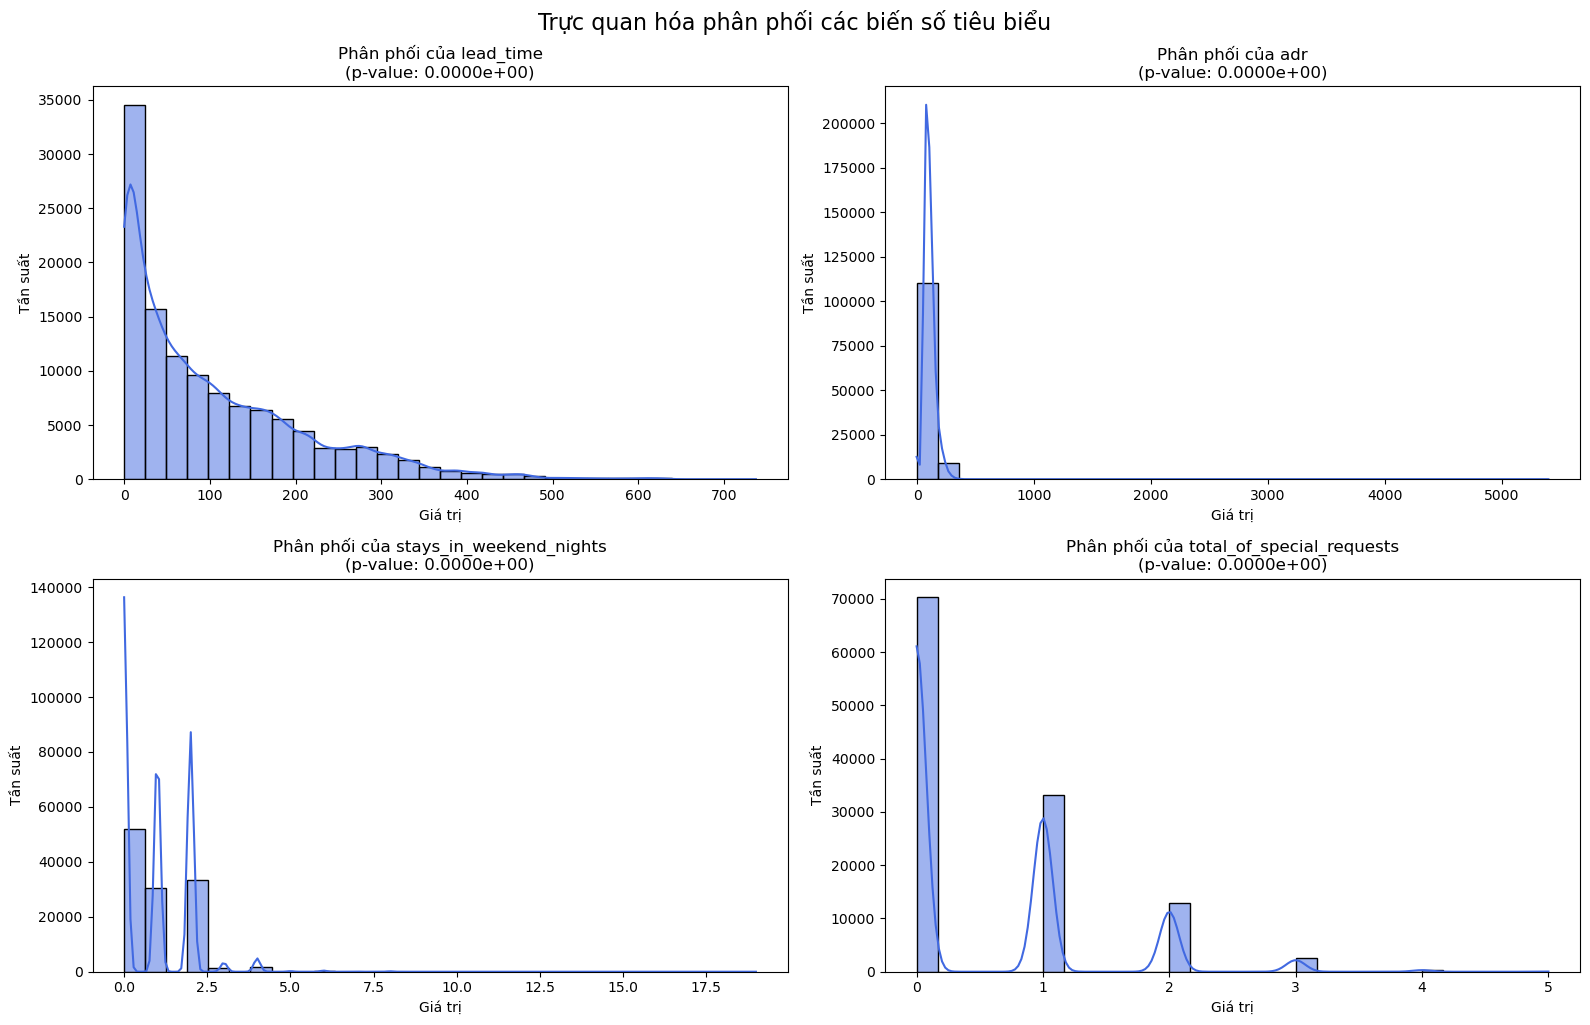

In [8]:


# 1. Xác định danh sách các thuộc tính số (Numerical features)
num_features = df.select_dtypes(include=[np.number]).columns.tolist()

# Loại bỏ các biến không phù hợp để kiểm định phân phối chuẩn liên tục
excluded_cols = ['is_canceled', 'arrival_date_year', 'arrival_date_day_of_month']
test_features = [col for col in num_features if col not in excluded_cols]

# 2. Khởi tạo danh sách lưu kết quả
results = []
alpha = 0.05

# 3. Thực hiện vòng lặp kiểm định cho từng thuộc tính
for col in test_features:
    # Loại bỏ giá trị null (NaN) trước khi kiểm định
    data = df[col].dropna()
    
    # Kiểm định D’Agostino-Pearson (phù hợp cho n > 5000)
    stat, p = stats.normaltest(data)
    
    # Phân loại phân phối dựa trên p-value
    dist_type = "Chuẩn (Normal)" if p > alpha else "Không chuẩn (Non-Normal)"
    recommendation = "StandardScaler (Z-score)" if p > alpha else "MinMaxScaler / RobustScaler"
    
    results.append({
        'Thuộc tính': col,
        'Thống kê K2': f"{stat:.2f}",
        'p-value': f"{p:.4e}",
        'Phân loại': dist_type,
        'Đề xuất chuẩn hóa': recommendation
    })

# 4. Chuyển kết quả thành DataFrame để hiển thị
summary_dist_df = pd.DataFrame(results)

print("KẾT QUẢ KIỂM ĐỊNH PHÂN PHỐI D'AGOSTINO-PEARSON")
display(summary_dist_df)

# 5. Trực quan hóa 4 biến tiêu biểu nhất để phân tích
top_visuals = ['lead_time', 'adr', 'stays_in_weekend_nights', 'total_of_special_requests']
plt.figure(figsize=(16, 10))

for i, col in enumerate(top_visuals):
    if col in df.columns:
        plt.subplot(2, 2, i+1)
        # Vẽ biểu đồ Histogram kèm đường KDE
        sns.histplot(df[col], kde=True, color='royalblue', bins=30)
        
        # Lấy p-value từ bảng kết quả để hiển thị lên tiêu đề
        p_val = summary_dist_df.loc[summary_dist_df['Thuộc tính'] == col, 'p-value'].values[0]
        plt.title(f"Phân phối của {col}\n(p-value: {p_val})")
        
        # Lưu ý: Đây là các dòng plt.xlabel và plt.ylabel đầy đủ
        plt.xlabel("Giá trị")
        plt.ylabel("Tần suất")

plt.tight_layout()
plt.suptitle("Trực quan hóa phân phối các biến số tiêu biểu", fontsize=16, y=1.02)
plt.show()


---

### **Cell Markdown: Phân tích kết quả kiểm định và Đề xuất chuẩn hóa**

---
Dựa trên kết quả bảng thống kê và các biểu đồ trực quan hóa vừa thực hiện, tôi có một số nhận xét, phân tích như sau

#### **1. Nhận xét tổng quan**
Dựa trên kết quả kiểm định **D’Agostino-Pearson** cho 17 thuộc tính số trong bộ dữ liệu *Hotel Booking Demand*:
*   **Kết quả thống kê:** Tất cả các thuộc tính đều có giá trị $p\text{-value}$ cực nhỏ ($0.0000e+00$ hoặc xấp xỉ $0$), thấp hơn rất nhiều so với mức ý nghĩa $\alpha = 0.05$.
*   **Kết luận:** Chúng ta có đủ bằng chứng thống kê để bác bỏ giả thuyết $H_0$ (giả thuyết về phân phối chuẩn). Do đó, **100% các thuộc tính số trong bộ dữ liệu không tuân theo phân phối chuẩn.**

#### **2. Phân tích chi tiết các biến tiêu biểu**
Từ các biểu đồ Histogram và đường ước lượng mật độ nhân (KDE), chúng ta có thể lý giải nguyên nhân dữ liệu không đạt tính chuẩn như sau:

*   **Biến `lead_time`:** Phân phối lệch phải (Positive Skewness) rất mạnh. Đa số khách hàng đặt phòng trong khoảng 0-100 ngày trước khi đến, nhưng có một "đuôi" rất dài kéo tới tận hơn 700 ngày. Điều này khiến cho trung bình (mean) bị kéo về phía phải và không trùng với trung vị (median).
*   **Biến `adr` (Average Daily Rate):** Đây là biến có phân phối tập trung cực cao ở khoảng giá thấp, nhưng xuất hiện các **giá trị ngoại lai (outliers) cực đoan** (lên tới hơn 5000). Sự hiện diện của các điểm dữ liệu cá biệt này làm biến dạng hoàn toàn hình dáng chuông của phân phối chuẩn.
*   **Biến `stays_in_weekend_nights` & `total_of_special_requests`:** Bản chất đây là các dữ liệu dạng đếm (count data) với các giá trị nguyên nhỏ (0, 1, 2...). Phân phối của chúng rời rạc và bị giới hạn dưới bởi giá trị 0, nên không thể tạo thành hình chuông đối xứng của phân phối chuẩn liên tục.

#### **3. Đề xuất phương pháp chuẩn hóa (Scaling)**
Vì không có thuộc tính nào tuân theo phân phối chuẩn, việc sử dụng *StandardScaler* (Z-score) sẽ không đạt hiệu quả tối ưu cho các mô hình nhạy cảm với phân phối. Nhóm đề xuất các hướng xử lý sau:

1.  **Ưu tiên MinMaxScaler:** Đối với các biến như `lead_time`, `arrival_date_week_number`, `stays_in_week_nights`. Phương pháp này sẽ đưa dữ liệu về khoảng $[0, 1]$, giúp giữ nguyên cấu trúc phân phối gốc và quan hệ tỉ lệ giữa các giá trị mà không giả định tính chuẩn.
2.  **Sử dụng RobustScaler cho biến `adr`:** Vì `adr` chứa các ngoại lai cực lớn (như đã thấy trên biểu đồ), `RobustScaler` sẽ sử dụng Trung vị (Median) và Khoảng cách tứ phân vị (IQR) để chuẩn hóa. Cách làm này giúp các giá trị ngoại lai không làm lệch (bias) các tham số chuẩn hóa của toàn bộ tập dữ liệu.
3.  **Cân nhắc Log Transformation (Nâng cao):** Với các biến lệch phải nặng như `lead_time`, có thể thực hiện phép biến đổi Logarit trước khi chuẩn hóa để làm giảm độ lệch, giúp phân phối trở nên "gần chuẩn" hơn, hỗ trợ tốt cho các mô hình tuyến tính.

--- 



# b. Phân tích tương quan đa biến

---

### **Lý thuyết Phân tích Tương quan và Đa cộng tuyến**

#### **1. Hệ số tương quan Pearson ($r$)**
Dùng để đo lường mức độ liên hệ **tuyến tính** giữa hai biến định lượng. 
*   **Công thức:** 
    $$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$
*   **Đặc điểm:** Nhạy cảm với các giá trị ngoại lai (outliers) và yêu cầu dữ liệu có phân phối chuẩn để đạt hiệu quả tốt nhất.

#### **2. Hệ số tương quan Spearman ($\rho$)**
Dùng để đo lường mối quan hệ **đơn điệu** (monotonic) dựa trên **thứ hạng (rank)** của dữ liệu thay vì giá trị thực tế.
*   **Công thức:** 
    $$\rho = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$$
    *(Trong đó $d_i$ là hiệu số giữa các thứ hạng của mỗi cặp quan sát)*.
*   **Ưu điểm:** Phù hợp với dữ liệu không chuẩn (như bộ dữ liệu Hotel Booking này) và ít bị ảnh hưởng bởi các giá trị ngoại lai.

#### **3. Hiện tượng Đa cộng tuyến (Multicollinearity)**
Xảy ra khi hai hoặc nhiều biến độc lập có tương quan rất mạnh với nhau ($|r| > 0.9$).
*   **Hậu quả:** Gây nhiễu cho mô hình (đặc biệt là Logistic Regression, Linear Regression), làm tăng phương sai của các hệ số hồi quy và khiến mô hình khó xác định được mức độ đóng góp thực sự của từng biến.
*   **Hướng xử lý:** 
    *   **Loại bỏ:** Giữ lại một biến có ý nghĩa nhất và loại bỏ biến còn lại.
    *   **Kết hợp:** Tạo ra một biến mới từ sự kết hợp của các biến tương quan (ví dụ: cộng dồn).
    *   **Giảm chiều:** Sử dụng PCA để trích chọn đặc trưng.

---

### **Cell 2: Python Code - Vẽ Heatmap và Xác định Đa cộng tuyến**



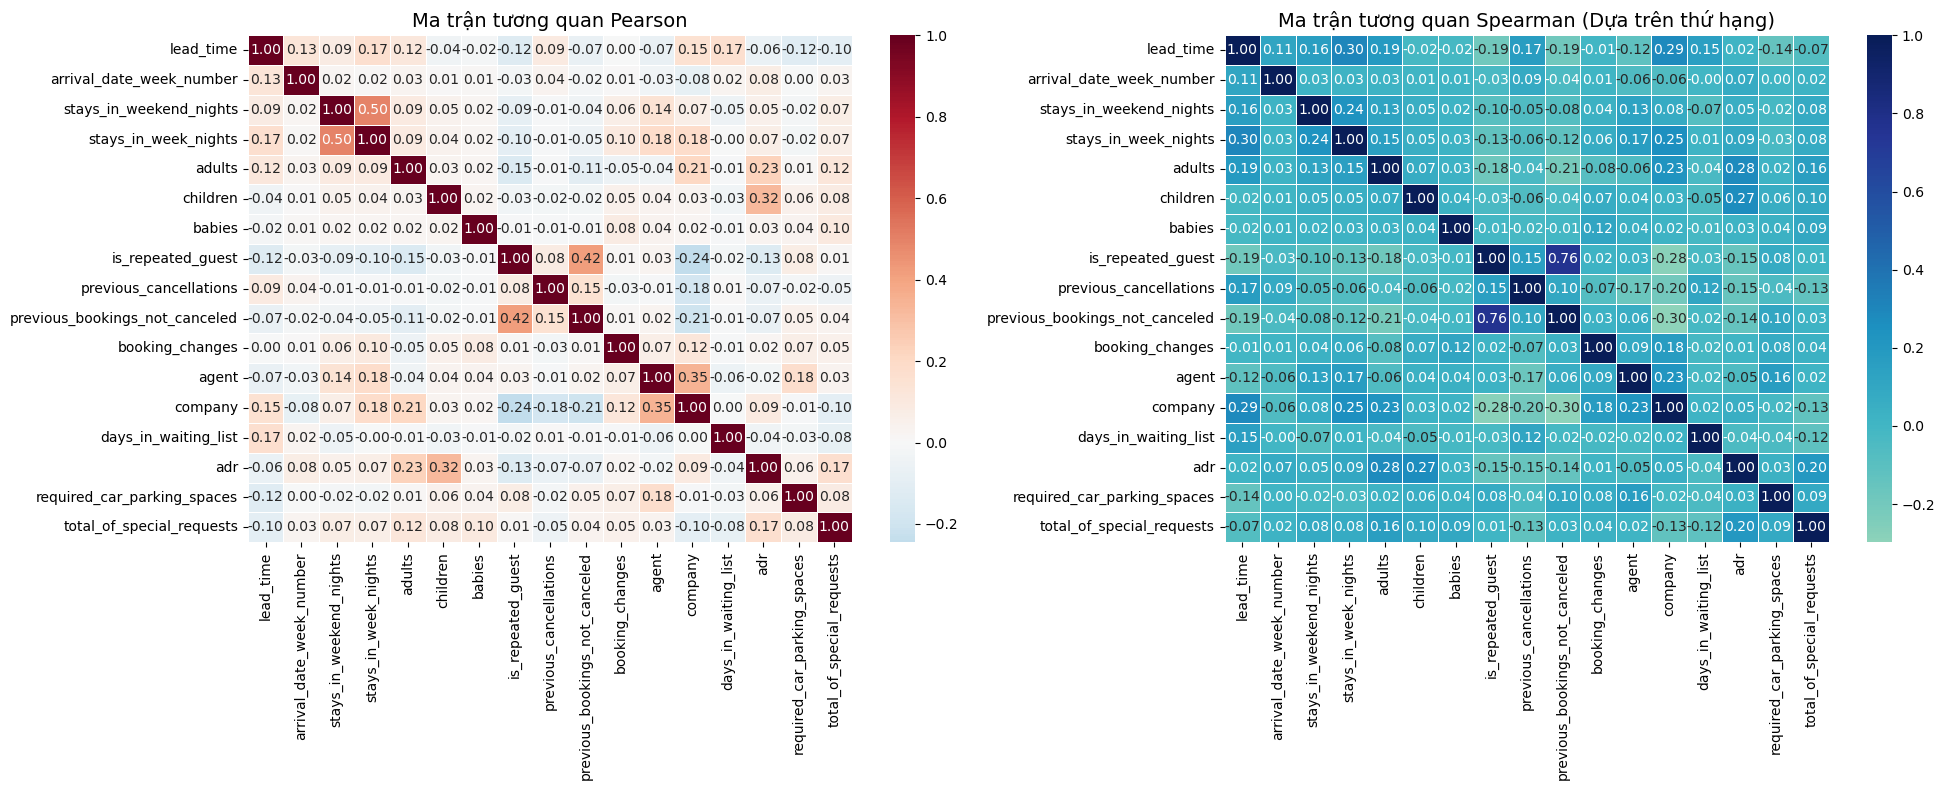

------------------------------
CÁC CẶP THUỘC TÍNH CÓ ĐA CỘNG TUYẾN MẠNH (|r| > 0.9):
------------------------------
Không phát hiện cặp thuộc tính nào có tương quan > 0.9.

------------------------------
ĐỀ XUẤT XỬ LÝ:
------------------------------
1. Nếu phát hiện tương quan rất mạnh giữa 'stays_in_weekend_nights' và 'stays_in_week_nights',
   có thể gộp thành biến 'total_nights' để giảm số lượng đặc trưng.
2. Các biến liên quan đến 'arrival_date_week_number' nếu tương quan cao với thời gian,
   cần cân nhắc giữ lại biến có khả năng giải thích tốt nhất cho mục tiêu dự báo.


In [9]:
# 1. Lấy danh sách các thuộc tính số (đã lọc ở bước trước)
# Lưu ý: dùng test_features đã xác định ở bước trước
numerical_df = df[test_features]

# 2. Tính toán ma trận tương quan Pearson và Spearman
pearson_corr = numerical_df.corr(method='pearson')
spearman_corr = numerical_df.corr(method='spearman')

# 3. Vẽ Heatmap so sánh
plt.figure(figsize=(20, 8))

# Heatmap Pearson
plt.subplot(1, 2, 1)
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5)
plt.title("Ma trận tương quan Pearson", fontsize=14)

# Heatmap Spearman
plt.subplot(1, 2, 2)
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap='YlGnBu', center=0, linewidths=0.5)
plt.title("Ma trận tương quan Spearman (Dựa trên thứ hạng)", fontsize=14)

plt.tight_layout()
plt.show()

# 4. Xác định các cặp thuộc tính có đa cộng tuyến mạnh (|r| > 0.9)
print("-" * 30)
print("CÁC CẶP THUỘC TÍNH CÓ ĐA CỘNG TUYẾN MẠNH (|r| > 0.9):")
print("-" * 30)

# Hàm tìm các cặp tương quan cao
def find_high_corr(corr_matrix, threshold=0.9):
    # Lấy nửa trên của ma trận tương quan (bỏ đường chéo chính)
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Tìm các cặp vượt ngưỡng
    high_corr_pairs = [(column, row, upper.loc[row, column]) 
                       for column in upper.columns 
                       for row in upper.index 
                       if abs(upper.loc[row, column]) > threshold]
    return high_corr_pairs

high_pearson = find_high_corr(pearson_corr)
high_spearman = find_high_corr(spearman_corr)

# In kết quả
if not high_pearson and not high_spearman:
    print("Không phát hiện cặp thuộc tính nào có tương quan > 0.9.")
else:
    if high_pearson:
        print("Theo Pearson:")
        for col1, col2, val in high_pearson:
            print(f"- {col1} và {col2}: {val:.4f}")
    if high_spearman:
        print("\nTheo Spearman:")
        for col1, col2, val in high_spearman:
            print(f"- {col1} và {col2}: {val:.4f}")

# 5. Đề xuất xử lý (Phân tích dựa trên thực tế dữ liệu)
print("\n" + "-" * 30)
print("ĐỀ XUẤT XỬ LÝ:")
print("-" * 30)
print("1. Nếu phát hiện tương quan rất mạnh giữa 'stays_in_weekend_nights' và 'stays_in_week_nights',")
print("   có thể gộp thành biến 'total_nights' để giảm số lượng đặc trưng.")
print("2. Các biến liên quan đến 'arrival_date_week_number' nếu tương quan cao với thời gian,")
print("   cần cân nhắc giữ lại biến có khả năng giải thích tốt nhất cho mục tiêu dự báo.")





### **Nhận xét kết quả Phân tích Tương quan Đa biến**

#### **1. So sánh giữa Heatmap Pearson và Spearman**
*   **Sự khác biệt về giá trị:**  Ta quan sát thấy các hệ số tương quan trong ma trận **Spearman** nhìn chung có xu hướng **cao hơn** so với ma trận Pearson (ví dụ: cặp `is_repeated_guest` và `previous_bookings_not_canceled` có hệ số Pearson là $0.42$ nhưng Spearman lên tới $0.76$).
*   **Lý do:** Ở bước kiểm định phân phối, chúng ta đã kết luận dữ liệu không tuân theo phân phối chuẩn và chứa nhiều ngoại lai. 
    *   **Pearson** đo lường mối quan hệ tuyến tính nên bị nhiễu bởi ngoại lai.
    *   **Spearman** đo lường mối quan hệ đơn điệu dựa trên thứ hạng (rank), nên phản ánh chính xác hơn bản chất liên kết giữa các biến trong bộ dữ liệu này.

#### **2. Các cặp thuộc tính có tương quan đáng chú ý**
Mặc dù không có cặp nào đạt ngưỡng đa cộng tuyến cực mạnh, nhưng có một số mối quan hệ cần lưu ý:
*   **`is_repeated_guest` và `previous_bookings_not_canceled` ($\rho = 0.76$):** Đây là mức tương quan mạnh nhất trong bộ dữ liệu. Điều này hoàn toàn hợp lý về mặt logic nghiệp vụ: khách hàng đã từng đặt phòng và không hủy trong quá khứ thường chính là những "khách hàng thân thiết" quay lại nhiều lần.
*   **`stays_in_week_nights` và `stays_in_weekend_nights` ($r = 0.50$):** Có mối tương quan thuận mức trung bình. Khách hàng có xu hướng kéo dài kỳ nghỉ từ trong tuần sang cuối tuần hoặc ngược lại.
*   **`adr` và `children` ($r = 0.32$):** Có sự tương quan nhẹ, cho thấy các booking có trẻ em đi kèm thường chọn các loại phòng lớn hơn hoặc dịch vụ cao cấp hơn, dẫn đến giá phòng trung bình cao hơn.

#### **3. Đánh giá hiện tượng Đa cộng tuyến (Multicollinearity)**
*   **Kết quả:** Dựa trên cả hai ma trận tương quan, **không có cặp thuộc tính nào có hệ số tương quan tuyệt đối $|r| > 0.9$.**
*   **Kết luận:** Hiện tượng đa cộng tuyến nghiêm trọng không xảy ra trong các biến số của bộ dữ liệu này. Điều này rất có lợi cho việc huấn luyện các mô hình học máy ở các giai đoạn sau (như Logistic Regression hoặc SVM) vì các biến độc lập không bị phụ thuộc lẫn nhau quá mức, giúp ước lượng hệ số mô hình ổn định và tin cậy hơn.

#### **4. Đề xuất xử lý**
*   Vì không phát hiện đa cộng tuyến mạnh ($>0.9$), chúng ta **không cần loại bỏ bất kỳ thuộc tính số nào** ở bước này.
*   Tuy nhiên, để tối ưu hóa đặc trưng (Feature Engineering), em nghĩ có thể xem xét gộp hai biến `stays_in_week_nights` và `stays_in_weekend_nights` thành một biến tổng `total_stays` để giảm số chiều mà không làm mất mát quá nhiều thông tin về độ dài lưu trú.

---



# c. Phân tích giá trị thiếu


---

## **Lý thuyết Kiểm định Little's MCAR**

### **1. Các cơ chế thiếu dữ liệu (Missing Data Mechanisms)**
Việc xác định cơ chế thiếu dữ liệu là tiền đề quan trọng để lựa chọn phương pháp điền khuyết phù hợp:
*   **MCAR (Missing Completely At Random):** Việc dữ liệu bị thiếu là hoàn toàn ngẫu nhiên, không phụ thuộc vào bất kỳ biến số nào khác.
*   **MAR (Missing At Random):** Việc thiếu dữ liệu có thể được giải thích thông qua các biến quan sát được trong tập dữ liệu.
*   **MNAR (Missing Not At Random):** Việc thiếu dữ liệu phụ thuộc vào chính giá trị của biến bị thiếu đó (trường hợp khó xử lý nhất).

### **2. Kiểm định Little's MCAR**
Kiểm định Little’s (1988) được sử dụng để kiểm chứng giả thuyết dữ liệu có thuộc cơ chế MCAR hay không bằng cách so sánh sự khác biệt giữa các trung bình nhóm của các mẫu hình thiếu dữ liệu.

*   **Công thức thống kê Chi-bình phương ($\chi^2$):**
    $$d^2 = \sum_{j=1}^{J} n_j (\bar{y}_j - \hat{\mu}_j)' \hat{\Sigma}_j^{-1} (\bar{y}_j - \hat{\mu}_j)$$
    Trong đó:
    - $J$: Số lượng các mẫu hình thiếu dữ liệu (missing patterns).
    - $n_j$: Số quan sát trong mẫu hình $j$.
    - $\bar{y}_j$: Trung bình quan sát được của mẫu hình $j$.
    - $\hat{\mu}_j$ và $\hat{\Sigma}_j$: Trung bình và ma trận hiệp phương sai tương ứng được trích xuất từ ước lượng tổng thể.
*   **Bậc tự do (Degrees of Freedom - DF):** Được tính bằng $DF = \sum k_j - p$, với $k_j$ là số biến quan sát được trong mẫu hình $j$ và $p$ là tổng số biến số có giá trị thiếu. Bậc tự do đóng vai trò quyết định trong việc xác định hình dạng phân phối $\chi^2$ để tính toán $p\text{-value}$.

*   **Giả thuyết:**
    - $H_0$: Dữ liệu thiếu hoàn toàn ngẫu nhiên (MCAR).
    - $H_1$: Dữ liệu không phải MCAR.
*   **Quy tắc quyết định:** Nếu $p\text{-value} < 0.05$, bác bỏ $H_0 \rightarrow$ Dữ liệu là MAR hoặc MNAR.

Tuy nhiên, trong thực tế với các tập dữ liệu quy mô lớn, việc cài đặt thủ công thuật toán này đòi hỏi xử lý ma trận phức tạp và dễ gặp lỗi suy biến.

### **3. Phương pháp thay thế: Kiểm định T-test trên biến chỉ báo (Indicator Variable)**
Để đảm bảo tính chính xác và tận dụng các thư viện thống kê chuẩn, nhóm sử dụng **Kiểm định T-test độc lập** để kiểm chứng cơ chế MCAR.

**Nguyên lý:** Nếu việc thiếu dữ liệu ở biến $A$ là hoàn toàn ngẫu nhiên (MCAR), thì trung bình của một biến $B$ bất kỳ sẽ không có sự khác biệt có ý nghĩa thống kê giữa nhóm "thiếu $A$" và nhóm "không thiếu $A$".

**Công thức toán học (T-test):**
$$t = \frac{\bar{X}_1 - \bar{X}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$
Trong đó:
- $\bar{X}_1, \bar{X}_2$: Trung bình của biến quan sát được ở hai nhóm (thiếu và không thiếu dữ liệu).
- $s_1^2, s_2^2$: Phương sai của hai nhóm.

**Giả thuyết thống kê:**
*   **$H_0$:** Trung bình của biến quan sát là như nhau ở cả hai nhóm ($p > 0.05 \rightarrow$ Chấp nhận MCAR).
*   **$H_1$:** Trung bình có sự khác biệt ý nghĩa ($p \leq 0.05 \rightarrow$ Bác bỏ MCAR, khẳng định cơ chế MAR).

---

## **Cell 2: Python Code - Trực quan hóa và Thực thi Kiểm định T-test**

---





BẢNG THỐNG KÊ GIÁ TRỊ THIẾU:


,Số lượng thiếu,Tỉ lệ (%)
children,4,0.003350
country,488,0.408744
agent,16340,13.686238
company,112593,94.306893


<Figure size 1200x600 with 0 Axes>

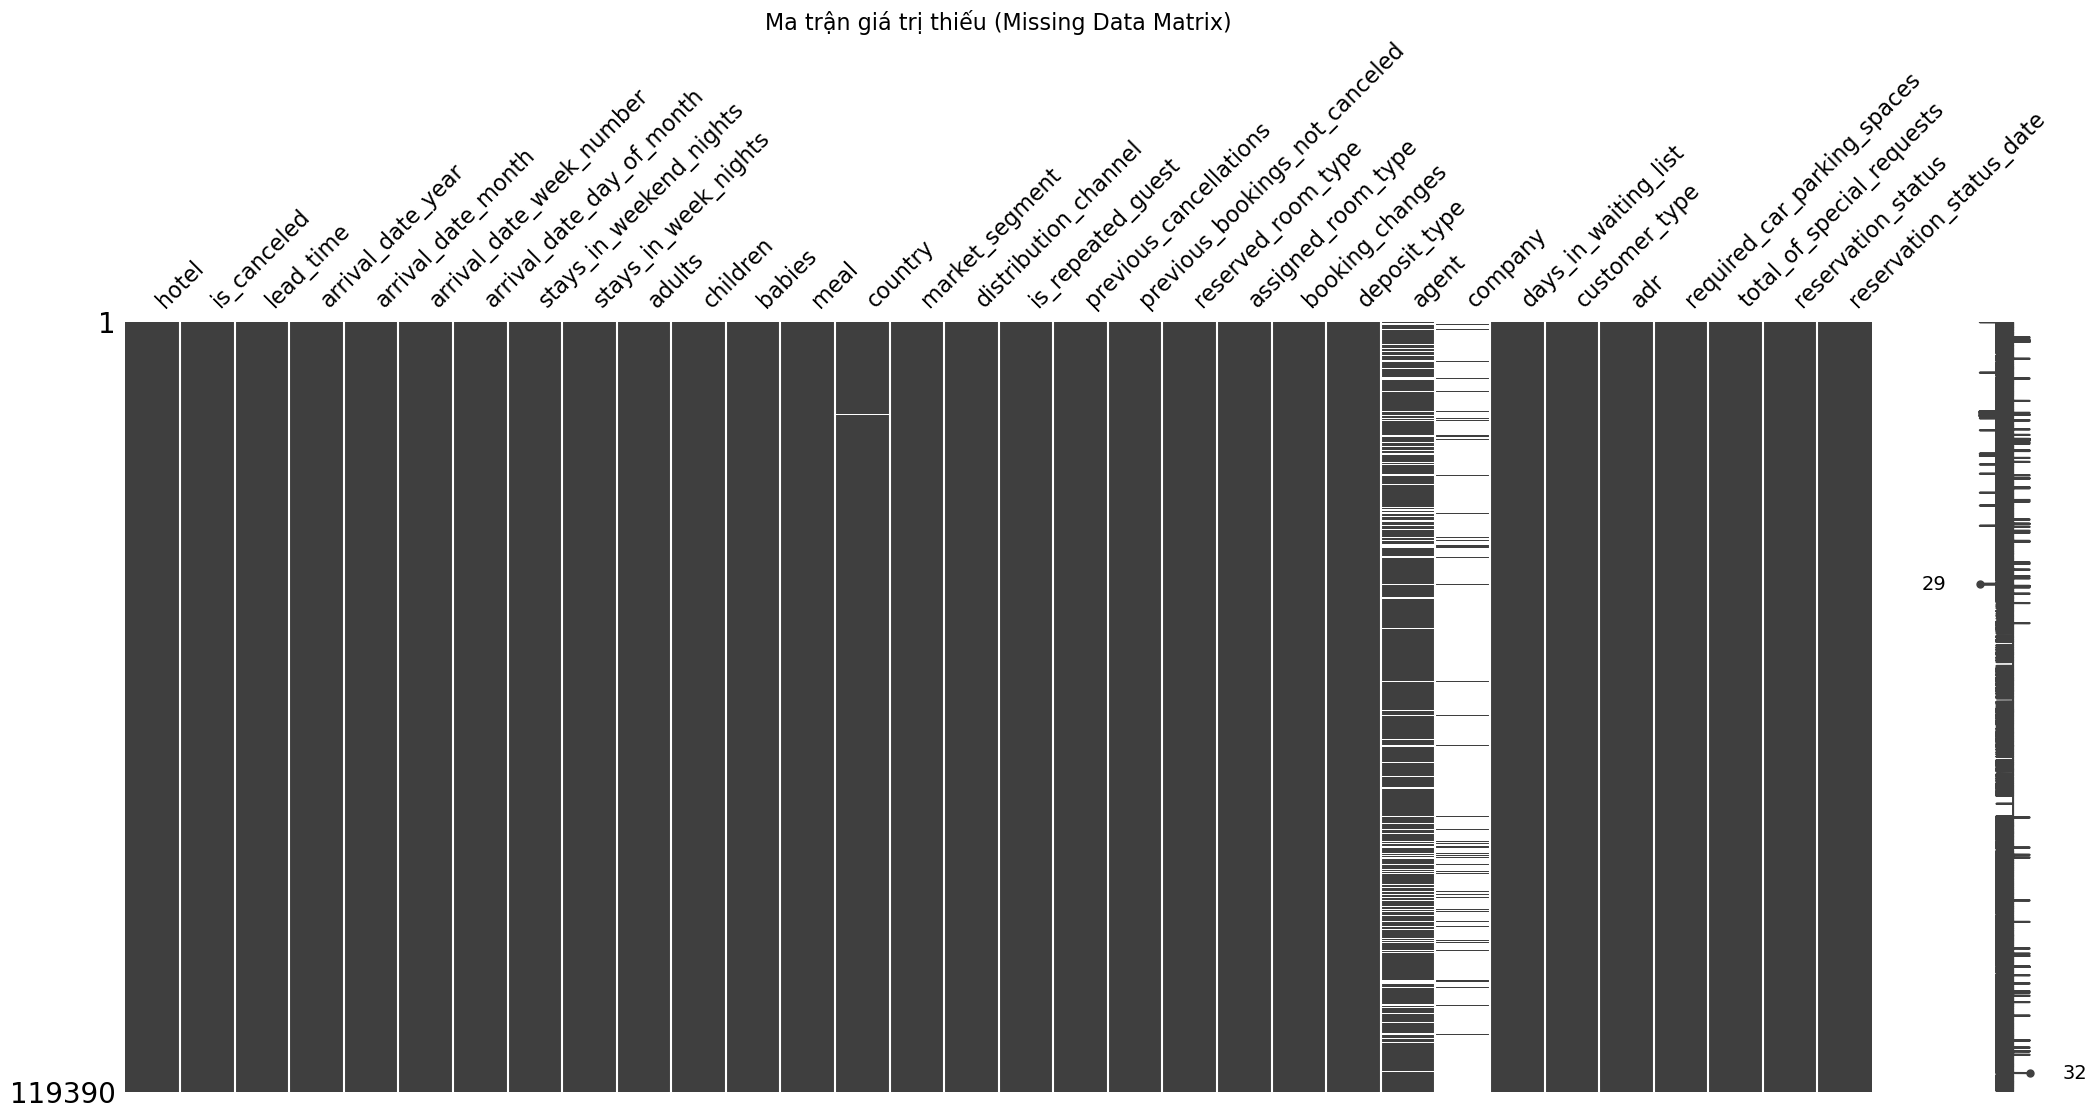

--- KIỂM ĐỊNH THỐNG KÊ CƠ CHẾ THIẾU CHO BIẾN 'agent' ---
Dựa trên biến quan sát: 'lead_time'
  - Trung bình lead_time (Nhóm thiếu agent): 55.70
  - Trung bình lead_time (Nhóm có agent): 111.67
  - p-value: 0.0000e+00
KẾT LUẬN: p-value < 0.05 => Bác bỏ giả thuyết MCAR.
Việc thiếu dữ liệu ở 'agent' phụ thuộc vào biến 'lead_time' (Cơ chế MAR).


In [11]:
from scipy import stats
import missingno as msno

# 1. Thống kê số lượng và tỉ lệ thiếu dữ liệu
missing_counts = df.isnull().sum()
missing_probs = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Số lượng thiếu': missing_counts, 'Tỉ lệ (%)': missing_probs})
print("BẢNG THỐNG KÊ GIÁ TRỊ THIẾU:")
display(missing_df[missing_df['Số lượng thiếu'] > 0])

# 2. Trực quan hóa Ma trận thiếu dữ liệu (Missingno Matrix)
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.title("Ma trận giá trị thiếu (Missing Data Matrix)", fontsize=16)
plt.show()

# 3. Thực thi Kiểm định T-test để chứng minh cơ chế thiếu (Thay thế Little's Test)
def test_missing_mechanism(data, target_col, observed_col):
    """
    Sử dụng T-test độc lập để kiểm tra xem việc thiếu target_col có phụ thuộc vào observed_col.
    """
    # Tạo biến chỉ báo (Indicator): True nếu thiếu, False nếu không thiếu
    is_missing = data[target_col].isnull()
    
    # Nhóm dữ liệu quan sát được dựa trên việc thiếu/không thiếu ở target_col
    group_missing = data[is_missing][observed_col].dropna()
    group_not_missing = data[~is_missing][observed_col].dropna()
    
    # Thực hiện t-test độc lập (Welch's t-test)
    t_stat, p_val = stats.ttest_ind(group_missing, group_not_missing, equal_var=False)
    
    print(f"--- KIỂM ĐỊNH THỐNG KÊ CƠ CHẾ THIẾU CHO BIẾN '{target_col}' ---")
    print(f"Dựa trên biến quan sát: '{observed_col}'")
    print(f"  - Trung bình {observed_col} (Nhóm thiếu {target_col}): {group_missing.mean():.2f}")
    print(f"  - Trung bình {observed_col} (Nhóm có {target_col}): {group_not_missing.mean():.2f}")
    print(f"  - p-value: {p_val:.4e}")
    
    if p_val < 0.05:
        print(f"KẾT LUẬN: p-value < 0.05 => Bác bỏ giả thuyết MCAR.")
        print(f"Việc thiếu dữ liệu ở '{target_col}' phụ thuộc vào biến '{observed_col}' (Cơ chế MAR).")
    else:
        print(f"KẾT LUẬN: p-value >= 0.05 => Chưa đủ bằng chứng bác bỏ MCAR.")

# Thực hiện kiểm định thực tế trên cột 'agent' (có tỉ lệ thiếu cao thứ 2)
# Chúng ta kiểm tra xem việc thiếu 'agent' có liên quan đến 'lead_time' không
test_missing_mechanism(df, 'agent', 'lead_time')


---

## **Phân tích và Nhận xét Cơ chế thiếu dữ liệu**

### **1. Thống kê tổng quan về dữ liệu thiếu**
Dựa trên bảng thống kê, bộ dữ liệu tồn tại giá trị thiếu ở 4 thuộc tính:
*   **`company`**: Thiếu **112,593 dòng (~94.31%)**. Đây là tỉ lệ thiếu cực kỳ cao, cho thấy trường thông tin này không bắt buộc và phần lớn khách hàng không thuộc diện đơn vị tổ chức.
*   **`agent`**: Thiếu **16,340 dòng (~13.69%)**. Tỉ lệ này đáng kể và cần được xử lý cẩn thận để không làm mất thông tin về kênh phân phối.
*   **`country`**: Thiếu **488 dòng (~0.41%)**.
*   **`children`**: Thiếu rất ít, chỉ **4 dòng (~0.003%)**.

### **2. Phân tích trực quan qua Ma trận Missingno**
Biểu đồ ma trận (`Missing Data Matrix`) cung cấp cái nhìn sâu hơn về cấu trúc thiếu:
*   Cột **`company`** gần như trống trải toàn bộ, thể hiện sự thiếu hụt mang tính hệ thống trên quy mô lớn.
*   Cột **`agent`** xuất hiện các mảng trắng xen kẽ một cách có quy luật. Điều này gợi ý rằng dữ liệu thiếu không phải là ngẫu nhiên mà gắn liền với các nhóm khách hàng hoặc hành vi đặt phòng cụ thể.

### **3. Kết quả kiểm định thống kê T-test**
Để xác định cơ chế thiếu cho biến `agent`, nhóm đã tiến hành so sánh biến `lead_time` giữa nhóm thiếu `agent` và nhóm có `agent`:
*   **Trung bình `lead_time` khi thiếu `agent`**: **55.70** ngày.
*   **Trung bình `lead_time` khi có `agent`**: **111.67** ngày.
*   **Giá trị p-value**: **0.0000e+00** (xấp xỉ bằng 0).

**Lập luận:** Vì $p\text{-value} < 0.05$, chúng ta có đủ bằng chứng thép để **bác bỏ giả thuyết MCAR**. Sự chênh lệch lớn về thời gian đặt phòng (nhóm có đại lý thường đặt trước rất lâu, nhóm thiếu đại lý thường đặt sát ngày) cho thấy việc thiếu dữ liệu ở `agent` phụ thuộc vào đặc điểm của booking đó.

### **4. Phân loại cơ chế thiếu và Giải thích nghiệp vụ**
Từ các minh chứng trên, nhóm phân loại cơ chế thiếu như sau:

*   **Cơ chế MAR (Missing At Random) - Áp dụng cho `agent` và `company`**:
    *   *Giải thích:* Dữ liệu thiếu có thể giải thích được thông qua các biến khác. Cụ thể, khi khách hàng đặt phòng trực tiếp (kênh *Direct*) hoặc khách lẻ (*Transient*), họ thường không thông qua đại lý du lịch (`agent`) hoặc không đại diện cho công ty (`company`). Do đó, thông tin này để trống là một sự thật khách quan phản ánh bản chất của loại hình đặt phòng đó.
*   **Cơ chế MCAR (Missing Completely At Random) - Áp dụng cho `country` và `children`**:
    *   *Giải thích:* Với tỉ lệ thiếu vô cùng thấp, đây có thể xem là những sai sót ngẫu nhiên trong quá trình nhập liệu thủ công của nhân viên hoặc lỗi hệ thống tạm thời tại thời điểm ghi nhận thông tin khách hàng.

### **5. Đề xuất hướng xử lý**
Do dữ liệu chủ yếu thuộc cơ chế **MAR**, việc sử dụng phương pháp xóa bỏ (Listwise Deletion) sẽ gây ra sai lệch lớn cho mô hình. Nhóm đề xuất:
*   Với **`agent`** và **`company`**: Sẽ được xử lý bằng cách điền một giá trị đại diện (như `0` hoặc `"Unknown"`) hoặc sử dụng kỹ thuật điền khuyết đa biến (MICE/k-NN) để giữ lại giá trị thông tin về kênh phân phối.
*   Với **`country`** và **`children`**: Có thể áp dụng phương pháp điền giá trị yếu vị (Mode) hoặc xóa bỏ vì số lượng dòng thiếu không đáng kể, không gây ảnh hưởng đến tổng thể.

---

